### Notes
- make sure to remove duplicated rows from the training data

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay,confusion_matrix

In [74]:
train_df = pd.read_csv("../data/training-with-satellite-features.csv")
train_df

,latitude,longitude,Occurrence Status,aet,def,pdsi,pet,ppt,q,soil,srad,swe,tmax,tmin,vap,vpd,ws
0,-34.027900,150.771000,1,53.500000,65.300003,-4.5,115.500000,49.7,2.5,16.700001,200.799149,0.0,23.9,12.599999,1.233,0.81,3.6
1,-34.821595,147.193697,1,24.700001,110.900002,-3.9,144.699997,25.9,1.3,2.500000,218.403992,0.0,24.5,10.900000,0.942,1.33,3.1
2,-36.617759,146.882941,0,51.299999,28.200001,-3.8,115.099998,69.9,3.5,68.800003,204.000031,0.0,21.4,8.099999,0.942,0.78,3.2
3,-37.470900,144.744000,1,40.299999,67.700005,-4.7,119.300003,45.2,2.3,12.400001,204.096054,0.0,20.1,8.000000,0.948,0.70,4.2
4,-38.400153,145.018560,1,58.900002,29.500000,-4.8,109.500000,71.1,3.6,43.000000,189.203964,0.0,18.9,9.900000,1.096,0.50,5.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6307,-33.877000,150.834000,1,51.400002,65.400002,-4.5,118.099998,50.9,2.5,15.200000,201.799423,0.0,24.1,13.099999,1.263,0.81,3.7
6308,-36.300563,140.975690,0,30.500000,90.800003,-2.6,127.800003,28.0,1.4,8.200000,212.802444,0.0,22.0,7.900000,0.998,0.92,3.8
6309,-37.882022,147.682533,1,36.799999,60.799999,-4.8,121.700005,38.0,1.9,5.900000,189.700104,0.0,21.5,9.900000,1.106,0.61,4.7
6310,-37.626000,143.763000,1,40.600002,47.100002,-3.8,111.200005,49.8,2.5,26.200001,200.999207,0.0,18.6,7.100000,0.941,0.58,4.4


In [75]:
# train_df.drop_duplicates(subset=["srad", "vap"], inplace=True)
train_df.shape

(6312, 17)

In [76]:
## Removing the duplicates using subset improves f1 score
X = train_df.drop(["longitude", "latitude", "Occurrence Status"], axis=1)
y = train_df["Occurrence Status"]

## Verifying reproducible zindi benchmark

In [ ]:
features = X.columns
# features = ["srad", "vap"]

# Define preprocessing steps
transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),  # Fill missing values with mean
        ("scaler", MinMaxScaler()),  # Scale numerical features
    ]
)


# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    [
        ("num", transformer, features),
    ],
    remainder="drop",
)

# Define the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Create the full pipeline
pipeline_old = Pipeline(
    [
        ("preprocessing", preprocessor),
        ("classifier", model)
    ]
)

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

def clean_training_data(X_train, y_train):
    duplicated_indices = X_train.duplicated()
    Xt = X_train[~duplicated_indices]
    yt = y_train[~duplicated_indices]
    return Xt, yt

X_train, y_train = clean_training_data(X_train, y_train)

# Train the pipeline
pipeline_old.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['aet', 'def', 'pdsi', 'pet', 'ppt', 'q', 'soil', 'srad', 'swe', 'tmax',
       'tmin', 'vap', 'vpd', 'ws'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [79]:
insample_predictions = pipeline_old.predict(X_train)
print(classification_report(y_train,insample_predictions))

              precision    recall  f1-score   support

           0       0.66      0.58      0.62      1662
           1       0.67      0.74      0.70      1902

    accuracy                           0.66      3564
   macro avg       0.66      0.66      0.66      3564
weighted avg       0.66      0.66      0.66      3564



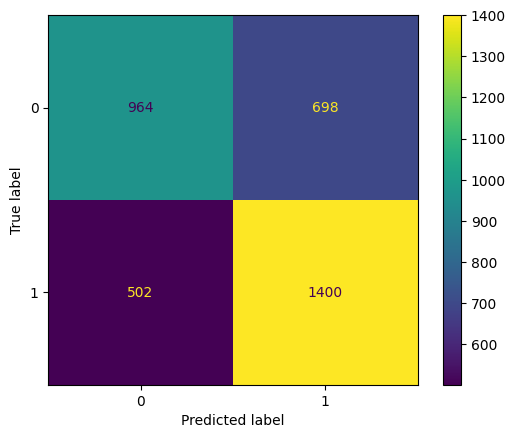

In [80]:
# Display confusion matrix.
ConfusionMatrixDisplay(confusion_matrix(y_train,insample_predictions)).plot()
plt.show()

In [81]:
# Make predictions and evaluate performance
outsample_predictions=pipeline_old.predict(X_test)
print(classification_report(y_test,outsample_predictions))

              precision    recall  f1-score   support

           0       0.63      0.59      0.61       756
           1       0.74      0.77      0.75      1138

    accuracy                           0.70      1894
   macro avg       0.68      0.68      0.68      1894
weighted avg       0.69      0.70      0.70      1894



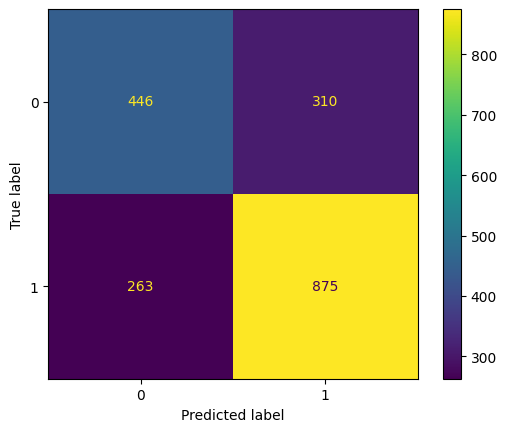

In [82]:
# Display confusion matrix.
ConfusionMatrixDisplay(confusion_matrix(y_test,outsample_predictions)).plot()

In [88]:
pd.DataFrame(pipeline_old.named_steps["classifier"].coef_, columns=X_train.columns).T.sort_values(by=0, ascending=False)

,0
ppt,2.198804
srad,1.963432
tmin,1.624037
aet,1.603151
vap,1.506501
q,1.405148
def,1.024146
pet,0.991086
swe,0.423973
ws,0.389785
